# Question 6
In this exercise, you will further analyze the Wage data set considered throughout this chapter.

In [1]:
from ISLP import load_data
import numpy as np

Wage = load_data('Wage')
Wage

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
...,...,...,...,...,...,...,...,...,...,...,...
2995,2008,44,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.041393,154.685293
2996,2007,30,2. Married,1. White,2. HS Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,2. No,4.602060,99.689464
2997,2005,27,2. Married,2. Black,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.193125,66.229408
2998,2005,27,1. Never Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,4.477121,87.981033


In [2]:
X = Wage[['age']] 
y = Wage['wage']

### (a) 
Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree $d$ for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

#### a.1 CV

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

np.random.seed(16)

max_degree = 10
cv_errors = []

kf = KFold(n_splits=10, shuffle=True, random_state=42) 

for d in range(1, max_degree + 1):
    poly_features = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=kf, scoring='neg_mean_squared_error')
    mean_mse = -scores.mean() 
    cv_errors.append(mean_mse)

optimal_degree_cv = np.argmin(cv_errors) + 1 
min_cv_error = min(cv_errors)

print("--- Polynomial Regression CV Errors (MSE) ---")
for d, error in enumerate(cv_errors, 1):
    print(f"Degree d={d}: MSE={error:.2f}")

print(f"\n[A-1] CV Optimal Degree d = {optimal_degree_cv} (Min CV Error = {min_cv_error:.2f})")

--- Polynomial Regression CV Errors (MSE) ---
Degree d=1: MSE=1677.50
Degree d=2: MSE=1600.90
Degree d=3: MSE=1597.00
Degree d=4: MSE=1595.88
Degree d=5: MSE=1595.98
Degree d=6: MSE=1595.84
Degree d=7: MSE=1594.73
Degree d=8: MSE=1594.05
Degree d=9: MSE=1596.43
Degree d=10: MSE=1603.87

[A-1] CV Optimal Degree d = 8 (Min CV Error = 1594.05)


#### a.2 ANOVA

In [4]:
X1 = sm.add_constant(X)
fit1 = sm.OLS(y, X1).fit()

poly2 = PolynomialFeatures(degree=2, include_bias=False)
X2_poly = poly2.fit_transform(X)
X2 = sm.add_constant(pd.DataFrame(X2_poly, columns=[f'age_{i}' for i in range(1, 3)])) 
fit2 = sm.OLS(y, X2).fit()

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X3_poly = poly3.fit_transform(X)
X3 = sm.add_constant(pd.DataFrame(X3_poly, columns=[f'age_{i}' for i in range(1, 4)]))
fit3 = sm.OLS(y, X3).fit()

poly4 = PolynomialFeatures(degree=4, include_bias=False)
X4_poly = poly4.fit_transform(X)
X4 = sm.add_constant(pd.DataFrame(X4_poly, columns=[f'age_{i}' for i in range(1, 5)]))
fit4 = sm.OLS(y, X4).fit()

print("\n--- ANOVA F-Test (Nested Models) ---")

anova_2_vs_1 = fit2.compare_f_test(fit1)
p_value_2 = anova_2_vs_1[1]
print(f"M1(d=1) vs M2(d=2): P-Value = {p_value_2:.4e} ({'Significant' if p_value_2 < 0.05 else 'Not Significant'})")

anova_3_vs_2 = fit3.compare_f_test(fit2)
p_value_3 = anova_3_vs_2[1]
print(f"M2(d=2) vs M3(d=3): P-Value = {p_value_3:.4e} ({'Significant' if p_value_3 < 0.05 else 'Not Significant'})")

anova_4_vs_3 = fit4.compare_f_test(fit3)
p_value_4 = anova_4_vs_3[1]
print(f"M3(d=3) vs M4(d=4): P-Value = {p_value_4:.4e} ({'Significant' if p_value_4 < 0.05 else 'Not Significant'})")

optimal_degree_anova = 1
if p_value_2 < 0.05:
    optimal_degree_anova = 2
if p_value_3 < 0.05:
    optimal_degree_anova = 3
if p_value_4 < 0.05:
    optimal_degree_anova = 4
    
print(f"\n[A-2] ANOVA Optimal Degree d = {optimal_degree_anova}")


--- ANOVA F-Test (Nested Models) ---
M1(d=1) vs M2(d=2): P-Value = 3.0774e-32 (Significant)
M2(d=2) vs M3(d=3): P-Value = 1.6871e-03 (Significant)
M3(d=3) vs M4(d=4): P-Value = 5.1039e-02 (Not Significant)

[A-2] ANOVA Optimal Degree d = 3


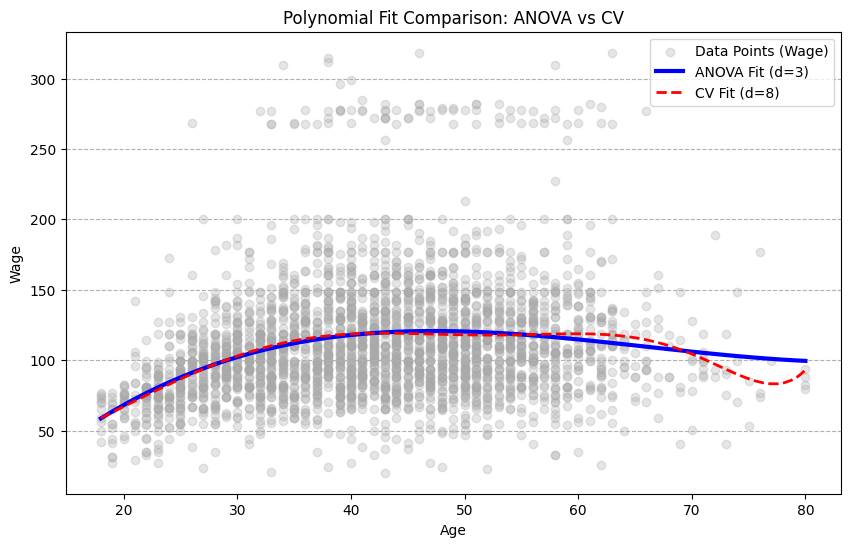

In [5]:
optimal_degree_cv = 8    
optimal_degree_anova = 3 

def fit_and_predict(degree, X_train, y_train, X_grid):
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_train = poly_features.fit_transform(X_train)
    X_fit_train = sm.add_constant(pd.DataFrame(X_poly_train))
    fit_model = sm.OLS(y_train, X_fit_train).fit()

    X_grid_poly_raw = poly_features.fit_transform(X_grid)
    X_grid_poly = sm.add_constant(pd.DataFrame(X_grid_poly_raw))
    
    X_grid_poly.columns = [col for col in fit_model.params.index]

    preds = fit_model.predict(X_grid_poly)
    return preds


age_grid = pd.DataFrame({'age': np.linspace(X['age'].min(), X['age'].max(), 100)})

preds_anova = fit_and_predict(optimal_degree_anova, X, y, age_grid)
preds_cv = fit_and_predict(optimal_degree_cv, X, y, age_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X['age'], y, color='darkgray', alpha=0.3, label='Data Points (Wage)') 

plt.plot(age_grid['age'], preds_anova, linewidth=3, color='blue', 
         label=f'ANOVA Fit (d={optimal_degree_anova})') 

plt.plot(age_grid['age'], preds_cv, linewidth=2, linestyle='--', color='red', 
         label=f'CV Fit (d={optimal_degree_cv})') 

plt.title('Polynomial Fit Comparison: ANOVA vs CV')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

### (b) 
Fit a step function to predict wage using age, and perform cross-validation to choose the optimal number of cuts. Make a plot of the fit obtained.

In [6]:
kf = KFold(n_splits=10, shuffle=True, random_state=16)

np.random.seed(42) 
max_cuts = 10
cv_errors_step = []

for num_cuts in range(1, max_cuts + 1):
    cut_points = np.quantile(X['age'], np.linspace(0, 1, num_cuts + 2)[1:-1])

    age_binned = pd.cut(X['age'], 
                        bins=[X['age'].min() - 1, *cut_points, X['age'].max() + 1])
    
    X_step = pd.get_dummies(age_binned, drop_first=True)

    model = LinearRegression()

    scores = cross_val_score(model, X_step, y, cv=kf, scoring='neg_mean_squared_error')
    
    mean_mse = -scores.mean() 
    cv_errors_step.append(mean_mse)

optimal_cuts_cv_step = np.argmin(cv_errors_step) + 1 
min_cv_error_step = min(cv_errors_step)

print("--- Step Function CV Errors (MSE) ---")
for k, error in enumerate(cv_errors_step, 1):
    print(f"Number of Cuts K={k} ({k+1} bins): MSE={error:.2f}")

print(f"\n[B-1] CV Optimal Cuts K = {optimal_cuts_cv_step} (Min CV Error = {min_cv_error_step:.2f})")

--- Step Function CV Errors (MSE) ---
Number of Cuts K=1 (2 bins): MSE=1703.92
Number of Cuts K=2 (3 bins): MSE=1660.14
Number of Cuts K=3 (4 bins): MSE=1640.60
Number of Cuts K=4 (5 bins): MSE=1637.17
Number of Cuts K=5 (6 bins): MSE=1629.30
Number of Cuts K=6 (7 bins): MSE=1621.38
Number of Cuts K=7 (8 bins): MSE=1619.45
Number of Cuts K=8 (9 bins): MSE=1617.91
Number of Cuts K=9 (10 bins): MSE=1613.78
Number of Cuts K=10 (11 bins): MSE=1617.32

[B-1] CV Optimal Cuts K = 9 (Min CV Error = 1613.78)


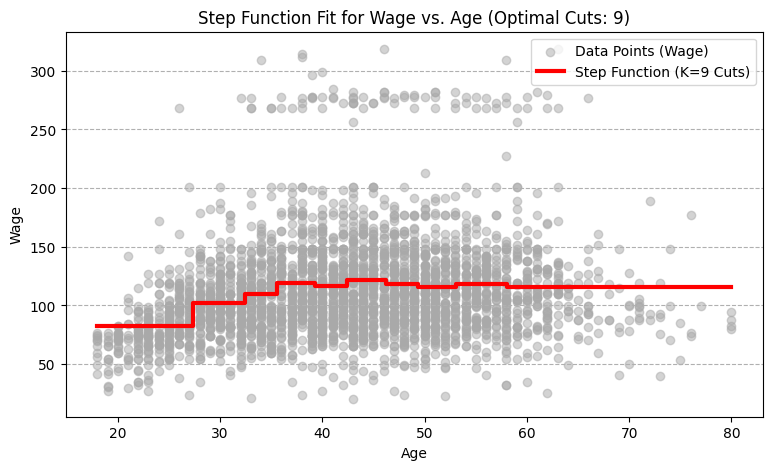

In [8]:
optimal_cut_points = np.quantile(X['age'], np.linspace(0, 1, optimal_cuts_cv_step + 2)[1:-1])

age_binned_best = pd.cut(X['age'], 
                        bins=[X['age'].min() - 1, *optimal_cut_points, X['age'].max() + 1])

X_step_best = pd.get_dummies(age_binned_best, drop_first=True).astype(float) 

X_step_best_sm = sm.add_constant(X_step_best)
fit_best_step = sm.OLS(y, X_step_best_sm).fit()

age_grid = pd.DataFrame({'age': np.linspace(X['age'].min(), X['age'].max(), 100)})

age_grid_binned = pd.cut(age_grid['age'], 
                        bins=[X['age'].min() - 1, *optimal_cut_points, X['age'].max() + 1])
X_grid_step = pd.get_dummies(age_grid_binned, drop_first=True).astype(float) # Grid data fix
X_grid_step_sm = sm.add_constant(X_grid_step)

missing_cols = set(X_step_best_sm.columns) - set(X_grid_step_sm.columns)
for c in missing_cols:
    X_grid_step_sm[c] = 0
X_grid_step_sm = X_grid_step_sm[X_step_best_sm.columns]

preds_step = fit_best_step.predict(X_grid_step_sm)

plt.figure(figsize=(9, 5))
plt.scatter(X['age'], y, color='darkgray', alpha=0.5, label='Data Points (Wage)')
plt.plot(age_grid['age'], preds_step, color='red', linewidth=3, drawstyle='steps-post', 
         label=f'Step Function (K={optimal_cuts_cv_step} Cuts)')
plt.title(f'Step Function Fit for Wage vs. Age (Optimal Cuts: {optimal_cuts_cv_step})')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()